In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


In [ ]:

!cp "/content/drive/MyDrive/archive.zip" .

# Extract
!mkdir -p data
!unzip -q archive.zip -d data/
print("Unzipped!")

Unzipped!


In [ ]:
!ls -la data/chest_xray/train
print("NORMAL/ PNEUMONIA folders ready!")

total 304
drwxr-xr-x 4 root root   4096 Jan  3 10:55 .
drwxr-xr-x 7 root root   4096 Jan  3 10:55 ..
drwxr-xr-x 2 root root  69632 Jan  3 10:55 NORMAL
drwxr-xr-x 2 root root 225280 Jan  3 10:55 PNEUMONIA
NORMAL/ PNEUMONIA folders ready!


In [ ]:
# Import necessary libraries for deep learning, data manipulation, and evaluation
import os
import numpy as np
from PIL import Image
from typing import Tuple, List, Optional
from tqdm import tqdm
from sklearn.model_selection import train_test_split # For splitting dataset into training and testing sets
import torch # For PyTorch deep learning framework
import torch
import torch.optim as optim # For optimization algorithms
import torch.nn as nn
from torchvision.models import vgg16 # Pretrained VGG16 model from torchvision
import matplotlib.pyplot as plt

In [ ]:
def load_data(
    base_dir: str, # Base directory containing image datasets
    target_size: Tuple[int, int] = (224, 224),
    max_normal_images: Optional[int] = None,
    max_pneumonia_images: Optional[int] = None
) -> Tuple[np.ndarray, np.ndarray]:
    images: List[np.ndarray] = []
    labels: List[int] = [] # List to store corresponding labels (0 or 1)

    normal_count = 0
    pneumonia_count = 0

    for subdir, _, files in os.walk(base_dir): # Traverse directories and files
        if "NORMAL" in subdir:
            label = 0
        elif "PNEUMONIA" in subdir:
            label = 1
        else:
            continue

        for file in tqdm(files, desc=f"Loading {os.path.basename(subdir)}"):
            if file.endswith(('.jpeg', '.jpg', '.png')):
                # Check for image limits
                if label == 0 and max_normal_images and normal_count >= max_normal_images:
                    continue
                if label == 1 and max_pneumonia_images and pneumonia_count >= max_pneumonia_images:
                    continue

                img_path = os.path.join(subdir, file)
                try:
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(target_size)

                    # --- FIX: Adding the missing logic below ---
                    images.append(np.array(img))
                    labels.append(label)

                    if label == 0: normal_count += 1
                    else: pneumonia_count += 1
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")

    return np.array(images), np.array(labels)

In [ ]:
import matplotlib.pyplot as plt

def plot_sample_images(images, labels, num_samples_per_class=5): # Split images by their labels: 0 for normal and 1 for pneumonia
    normal_images = images[labels == 0]
    pneumonia_images = images[labels == 1]

    # Set the number of images to display
    num_normal = min(len(normal_images), num_samples_per_class)
    num_pneumonia = min(len(pneumonia_images), num_samples_per_class)

    plt.figure(figsize=(20, 10))

    for i in range(num_normal):
        plt.subplot(2, num_samples_per_class, i + 1)
        plt.imshow(normal_images[i])
        plt.axis('off')
        plt.title("NORMAL")

    for i in range(num_pneumonia):
        plt.subplot(2, num_samples_per_class, num_samples_per_class + i + 1)
        plt.imshow(pneumonia_images[i])
        plt.axis('off')
        plt.title("PNEUMONIA")

    plt.tight_layout()
    plt.show()

Loading PNEUMONIA: 100%|██████████| 3876/3876 [00:10<00:00, 362.84it/s]


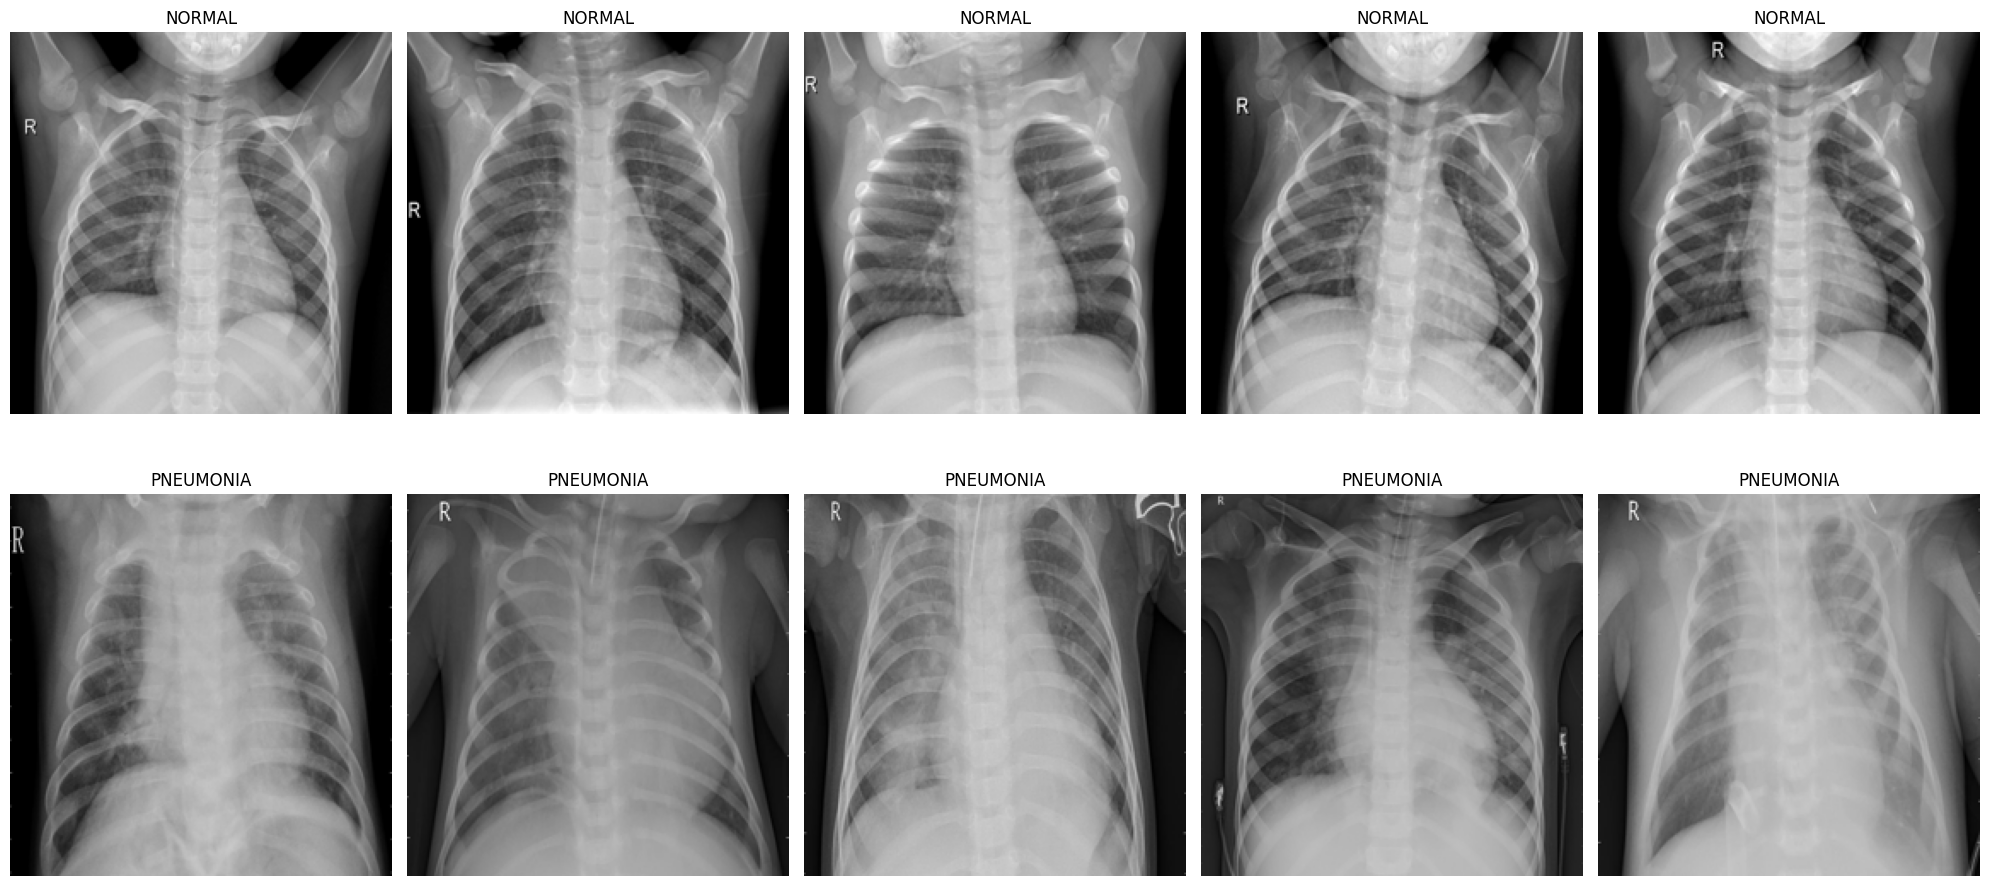

In [ ]:
base_dir = '/content/data/chest_xray/chest_xray/train'
images, labels = load_data(base_dir, max_normal_images=700, max_pneumonia_images=700)

plot_sample_images(images, labels, num_samples_per_class=5)

In [ ]:
from torchvision.models import vgg16, VGG16_Weights
import torch.nn as nn

def initialize_model():
    model = vgg16(weights=VGG16_Weights.DEFAULT)

    num_features = model.classifier[6].in_features
    # Binary classification: outputting 1 value for Pneumonia detection
    model.classifier[6] = nn.Linear(num_features, 1)

    return model


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_client(model, x_train, y_train, epochs, batch_size):
    model.train()
    device = next(model.parameters()).device

    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    # Labels must be [N, 1] for BCEWithLogitsLoss
    y_train = y_train.unsqueeze(1)

    # x_train must already be a tensor of shape [N, 3, 224, 224]
    dataset = torch.utils.data.TensorDataset(x_train, y_train)
    dataloader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    for epoch in range(epochs):
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()

    return model.state_dict(), loss.item()


In [ ]:
import torch
import torch.nn as nn

def federated_averaging(client_weights):
    # Create a new dictionary to avoid modifying client_weights[0] in-place
    global_weights = {}

    for key in client_weights[0].keys():
        global_weights[key] = torch.stack(
            [weights[key].float() for weights in client_weights],
            dim=0
        ).mean(dim=0)

    return global_weights


def validate_global_model(model, x_val, y_val):
    model.eval()
    device = next(model.parameters()).device
    loss_fn = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        x_val = x_val.to(device)
        y_val = y_val.unsqueeze(1).to(device)

        outputs = model(x_val)
        loss = loss_fn(outputs, y_val)

        predictions = torch.sigmoid(outputs) > 0.5
        accuracy = (predictions == y_val).sum().item() / len(y_val)

    return loss.item(), accuracy * 100



In [ ]:
def federated_learning(clients_data, global_model, epochs, rounds, batch_size, validation_data):
    x_val, y_val = validation_data
    device = next(global_model.parameters()).device

    for round_num in range(rounds):
        print(f"\n### Federated Learning Round {round_num + 1}/{rounds} ###")
        client_weights = []

        for client_id, (x_train, y_train) in enumerate(clients_data):
            print(f"Training on client {client_id + 1}/{len(clients_data)}")

            local_model = initialize_model().to(device)
            local_model.load_state_dict(global_model.state_dict())

            weights, _ = train_client(
                local_model,
                x_train,
                y_train,
                epochs,
                batch_size
            )

            client_weights.append(weights)

        global_weights = federated_averaging(client_weights)
        global_model.load_state_dict(global_weights)

        val_loss, val_acc = validate_global_model(
            global_model,
            x_val,
            y_val
        )

        print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Load and Normalize
base_dir = '/content/data/chest_xray/chest_xray/train'
images, labels = load_data(
    base_dir,
    max_normal_images=700,
    max_pneumonia_images=700
)

# Normalize to [0, 1]
images = images / 255.0

# Split into Train / Validation / Test
x_train, x_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    train_size=0.8,
    random_state=42
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)


Loading PNEUMONIA: 100%|██████████| 3876/3876 [00:10<00:00, 363.83it/s]


In [ ]:
import torch

# Convert to Tensors and fix dimensions (HWC → CHW)
x_train_tensor = torch.from_numpy(x_train).permute(0, 3, 1, 2).float()
y_train_tensor = torch.from_numpy(y_train).float()

x_val_tensor = torch.from_numpy(x_val).permute(0, 3, 1, 2).float()
y_val_tensor = torch.from_numpy(y_val).float()

# Verify shape → [N, 3, 224, 224]
print(f"Corrected x_train shape: {x_train_tensor.shape}")


Corrected x_train shape: torch.Size([1120, 3, 224, 224])


In [ ]:
# Federated Splitting (USE TENSORS)
num_clients = 3
client_data_size = len(x_train_tensor) // num_clients

clients_data = []
for i in range(num_clients):
    start = i * client_data_size
    end = (i + 1) * client_data_size
    clients_data.append((
        x_train_tensor[start:end],
        y_train_tensor[start:end]
    ))

print(f"Data split among {num_clients} clients.")


Data split among 3 clients.


In [ ]:
# Initialize global model and device
global_model = initialize_model()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_model.to(device)

# Train with federated learning
federated_learning(
    clients_data=clients_data,
    global_model=global_model,
    epochs=2,
    rounds=3,
    batch_size=16,
    validation_data=(x_val_tensor, y_val_tensor)  # USE TENSORS
)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 187MB/s]



### Federated Learning Round 1/3 ###
Training on client 1/3
Training on client 2/3
Training on client 3/3
Validation Loss: 0.1546, Validation Accuracy: 92.86%

### Federated Learning Round 2/3 ###
Training on client 1/3
Training on client 2/3
Training on client 3/3
Validation Loss: 0.2343, Validation Accuracy: 92.14%

### Federated Learning Round 3/3 ###
Training on client 1/3
Training on client 2/3
Training on client 3/3
Validation Loss: 0.3130, Validation Accuracy: 92.14%


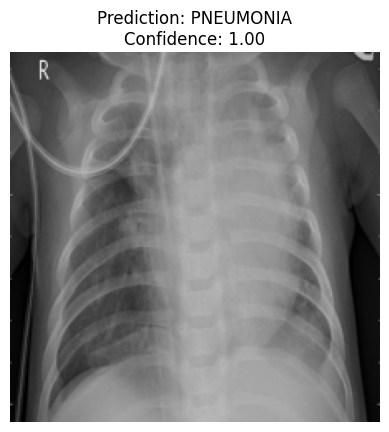

Predicted Class: PNEUMONIA
Pneumonia Probability: 0.9999984502792358


In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -------- CONFIG --------
IMAGE_PATH = "/content/data/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg"
# You can change this to any image from NORMAL / PNEUMONIA folder

# -------- LOAD & PREPROCESS IMAGE --------
img = Image.open(IMAGE_PATH).convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img) / 255.0  # normalize
img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).float()

# Move to device
img_tensor = img_tensor.to(device)

# -------- MODEL INFERENCE --------
global_model.eval()
with torch.no_grad():
    output = global_model(img_tensor)
    prob = torch.sigmoid(output).item()

prediction = "PNEUMONIA" if prob > 0.5 else "NORMAL"

# -------- DISPLAY RESULT --------
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {prediction}\nConfidence: {prob:.2f}")
plt.show()

print("Predicted Class:", prediction)
print("Pneumonia Probability:", prob)


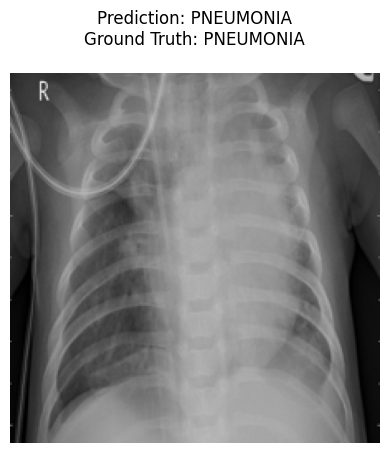

Prediction : PNEUMONIA
Ground Truth: PNEUMONIA


In [ ]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# -------- CONFIG --------
IMAGE_PATH = "/content/data/chest_xray/test/PNEUMONIA/person100_bacteria_479.jpeg"
# Change to any image from NORMAL or PNEUMONIA folder

# -------- LOAD & PREPROCESS IMAGE --------
img = Image.open(IMAGE_PATH).convert("RGB")
img = img.resize((224, 224))

img_array = np.array(img) / 255.0
img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).unsqueeze(0).float()
img_tensor = img_tensor.to(device)

# -------- GROUND TRUTH (FROM FOLDER NAME) --------
true_label = "PNEUMONIA" if "PNEUMONIA" in IMAGE_PATH else "NORMAL"

# -------- MODEL INFERENCE --------
global_model.eval()
with torch.no_grad():
    output = global_model(img_tensor)
    prediction = "PNEUMONIA" if torch.sigmoid(output).item() > 0.5 else "NORMAL"



# -------- DISPLAY --------
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {prediction}\n"
    f"Ground Truth: {true_label}\n"

)
plt.show()

print("Prediction :", prediction)
print("Ground Truth:", true_label)



In [ ]:
import torch

torch.save(global_model.state_dict(), "federated_vgg.pt")

print("Model saved successfully!")

In [ ]:
from google.colab import files
files.download("federated_vgg.pt")